# Lab 2

### Accel FFT

Sample rate:  245.9339576145885
T:  0.004066132264529058


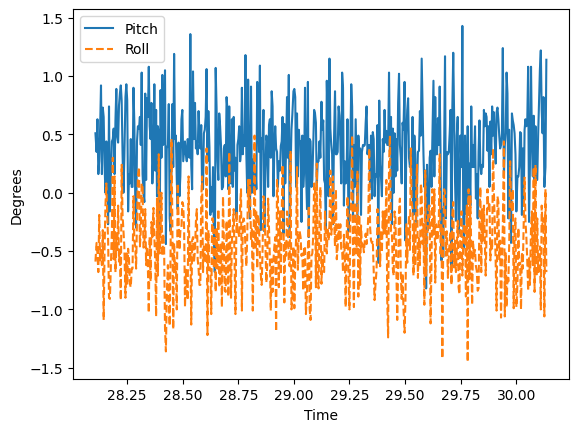

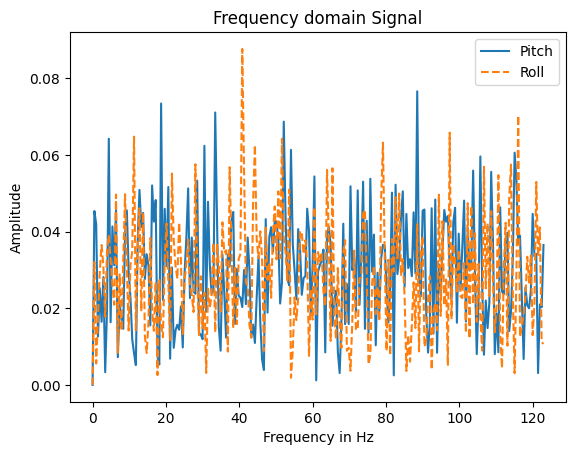

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("AccelNoiseNoDelay.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
print("T: ", T)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

### Calculating Alpha

In [30]:
from math import pi
from IPython.display import display, Markdown

fc = 25
T  = 0.004066132264529058

rc = 1/(2*pi*fc)
alpha = T/(T + rc)

md = rf"""
$$
RC = \frac{{1}}{{2\pi \cdot {fc}}}
    = {rc:.12g}
$$

$$
\alpha = \frac{{{T:.12g}}}{{{T:.12g} + {rc:.12g}}}
       = {alpha:.12g}
$$
"""
display(Markdown(md))



$$
RC = \frac{1}{2\pi \cdot 25}
    = 0.00636619772368
$$

$$
\alpha = \frac{0.00406613226453}{0.00406613226453 + 0.00636619772368}
       = 0.38976261958
$$


### Accel Low Pass FFT

Sample rate:  250.025012506253


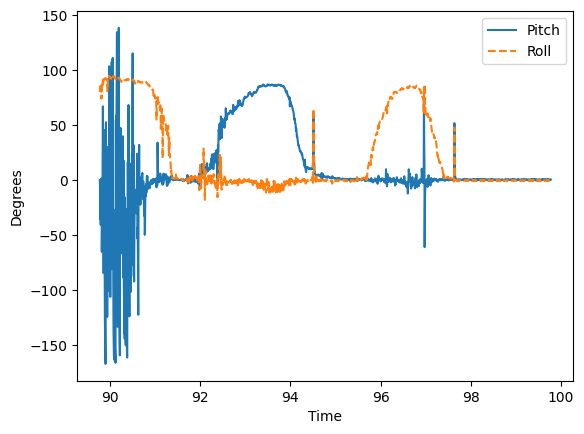

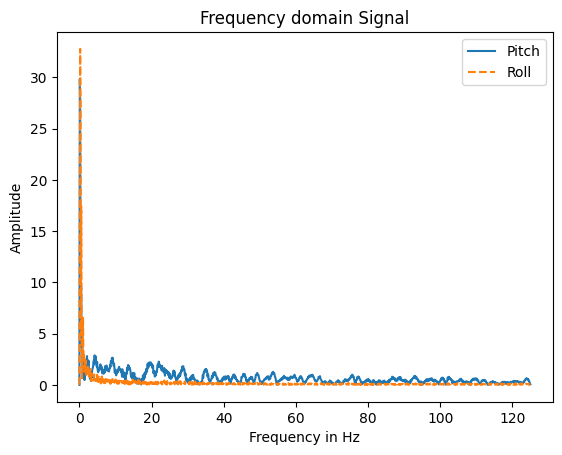

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("LowPass0.4ND2.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

### Low Pass and Original Values

Sample rate: 28.57142857142858


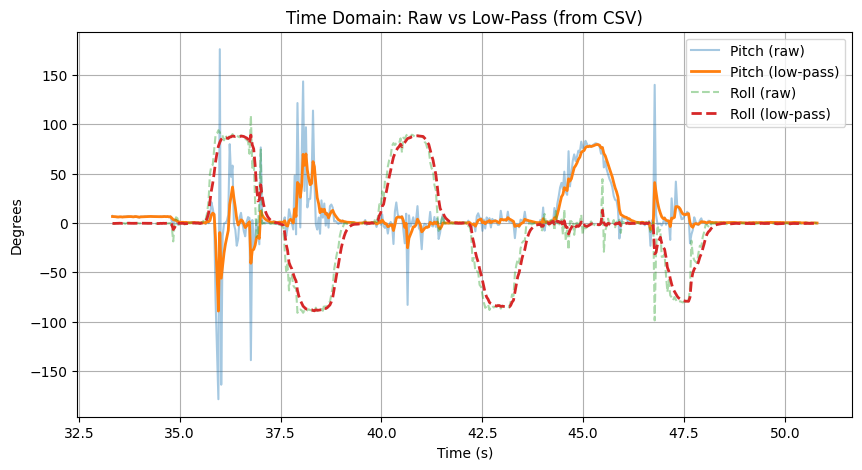

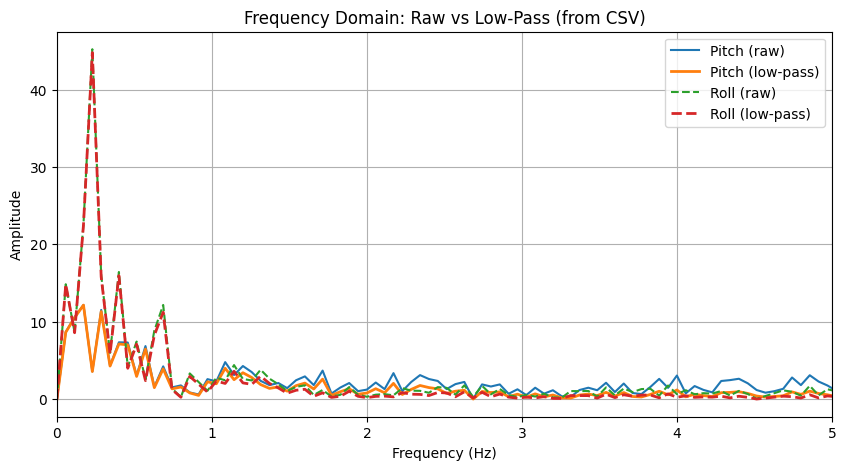

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ======================
# Load the CSV
# ======================
df = pd.read_csv("AllData.csv")

pitch    = df["Pitch"].to_numpy()
roll     = df["Roll"].to_numpy()
pitch_lp = df["Pitch_LPF"].to_numpy()
roll_lp  = df["Roll_LPF"].to_numpy()
t        = df["Time"].to_numpy() / 1000.0

# ======================
# Sample rate
# ======================
dt = np.diff(t)
T = np.mean(dt)
sample_rate = 1.0 / T
print("Sample rate:", sample_rate)

N = len(pitch)

# ======================
# Time-domain plot
# ======================
plt.figure(figsize=(10, 5))
plt.plot(t, pitch, label="Pitch (raw)", alpha=0.4)
plt.plot(t, pitch_lp, label="Pitch (low-pass)", linewidth=2)

plt.plot(t, roll, label="Roll (raw)", alpha=0.4, linestyle="--")
plt.plot(t, roll_lp, label="Roll (low-pass)", linewidth=2, linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Degrees")
plt.title("Time Domain: Raw vs Low-Pass (from CSV)")
plt.legend()
plt.grid(True)
plt.show()

# ======================
# Frequency-domain plot
# ======================
def spectrum(x):
    x0 = x - np.mean(x)
    X = np.fft.rfft(x0)
    return (2 / N) * np.abs(X)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

plt.figure(figsize=(10, 5))
plt.plot(frequency, spectrum(pitch), label="Pitch (raw)")
plt.plot(frequency, spectrum(pitch_lp), label="Pitch (low-pass)", linewidth=2)

plt.plot(frequency, spectrum(roll), label="Roll (raw)", linestyle="--")
plt.plot(frequency, spectrum(roll_lp), label="Roll (low-pass)", linestyle="--", linewidth=2)

plt.xlim(0, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain: Raw vs Low-Pass (from CSV)")
plt.legend()
plt.grid(True)
plt.show()


### Gyro Roll Pitch Yaw

Sample rate:  71.64564220183485
T:  0.013957583033213287


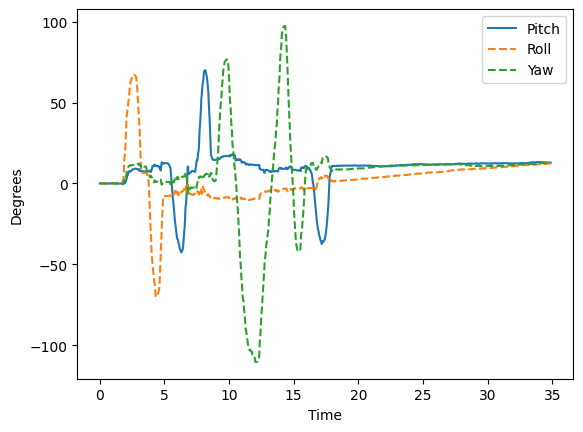

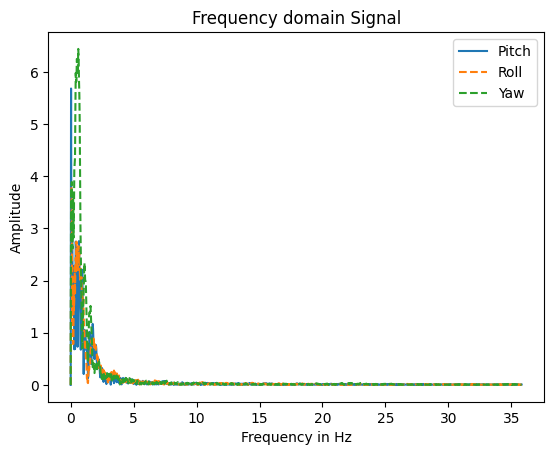

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("GyroRPY.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
yaw = df["Yaw"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
print("T: ", T)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.plot(t, yaw, label="Yaw", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)
yaw0  = yaw  - np.mean(yaw)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)
freq_yaw  = np.fft.rfft(yaw0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)
y_yaw = (2/N) * np.abs(freq_yaw)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.plot(frequency, y_yaw, label="Yaw", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()